In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys

In [2]:
print(cv2.__version__)       
print(np.__version__)        

5.0.0
2.5.1


In [3]:
import time

def calculate_fps(time_diffs):
    np_array = np.array(time_diffs)
    mean_val = np_array.mean()
    return 1/mean_val

In [4]:
def draw_fps(frame, fps):
    fps_text = f"FPS: {fps:.1f}"
    return cv2.putText(
        frame, 
        fps_text, 
        (10, 40), 
        cv2.FONT_HERSHEY_SIMPLEX, 
        1, 
        (0, 255, 0),  # Green text
        2, 
        cv2.LINE_AA
    )

In [5]:
def create_mask(bgr_frame):
    # BGR to HSV
    hsv_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2HSV)

    # red
    lower_red01 = np.array([0, 120, 70])
    upper_red01 = np.array([10, 255, 255])
    lower_red02 = np.array([170,120,70])
    upper_red02 = np.array([180,255,255])
    
    mask01 = cv2.inRange(hsv_frame, lower_red01, upper_red01)
    mask02 = cv2.inRange(hsv_frame, lower_red02, upper_red02)
    
    return cv2.bitwise_or(mask01, mask02)

In [6]:
def find_objects(mask):
    # maskClean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))
    contours, hierarchy = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE)

    threshold = 500
    objects = []
    
    for contour in contours:
        area = cv2.contourArea(contour)
        if area < threshold:
            continue
        x, y, w, h = cv2.boundingRect(contour)
        cx = x + w // 2
        cy = y + h // 2
        objects.append((cx, cy, area, (x, y, w, h)))

    return objects

In [7]:
import transform

In [8]:
def pixel_to_world(center_xy, image_size, scale, angle):
    w, h = image_size
    R = transform.rotation_matrix_2d(angle)
    S = transform.scale_matrix_2d(scale, scale)

    rel_position = transform.translate_2d(center_xy, - w / 2.0, - h / 2.0) # translation
    scaled = S @ rel_position # scaling
    angled = R @ scaled # rotation
    return angled

In [24]:
def draw_detection(frame, detected_objects, image_size, scale, angle):
    wx = wy = None
    for cx, cy, area, (x, y, w, h) in detected_objects:

        greenBGR = (0, 255, 0)
        thickness = 2
        cv2.rectangle(frame, (x, y), (x + w, y + h), greenBGR, thickness)

        redBGR = (0,0,255)
        radius = 4
        cv2.circle(frame, (cx, cy), radius, redBGR, -1)

        wx, wy = pixel_to_world((cx, cy), image_size, scale, angle)
        text = f"px({cx}, {cy})\nworld({wx:.2f}, {wy:.2f})"
        text_position = (cx + 20, cy)
        
        cv2.putText(
            frame,
            text,
            text_position,
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            redBGR,
            1,
            cv2.LINE_AA
        )

    return frame, (wx, wy)        

In [25]:
def detect(frame, image_size, scale, angle):
    masked = create_mask(frame) # white objects, black background
    detected_objects = find_objects(masked) # detect boundaries
    if not detected_objects:
        return (frame, masked, [], None, None)
    largest = [max(detected_objects, key=lambda o: o[2])]
    result, world_coor = draw_detection(frame, largest, image_size, scale, angle) # draw bounding boxes on the original frame

    # largest[0] is (cx, cy, area, (x, y, w, h))
    pixel_coor = (largest[0][0], largest[0][1])
    # print(f"중심: ({world_coor[0]}, {world_coor[1]}) | 면적: {largest[0][2]}px²")
    return (result, masked, detected_objects, pixel_coor, world_coor)

In [26]:
from collections import deque

In [35]:
def main():
    # ---------------- Camera Initialization ----------------
    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print("카메라를 열 수 없습니다.")
        sys.exit()

    width = 640
    height = 480
    image_size = (width, height)

    cap.set(cv2.CAP_PROP_FRAME_WIDTH, width)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, height)

    print("웹캠 연결 성공")

    # ---------------- Coordinate History ----------------
    pixel_coor_list = deque(maxlen=100)
    world_coor_list = deque(maxlen=100)

    # ---------------- FPS ----------------
    time_diffs = deque(maxlen=30)
    previous_time = time.time()

    # ---------------- Plot ----------------
    plt.ion()
    fig, ax = plt.subplots()
 
    ax.set_title("Pixel & World Coordinates")
    pixel_sc = ax.scatter([], [], color='blue', label='Pixel')
    world_sc  = ax.scatter([], [], color='red', label='World')

    ax.set_xlim(0, 640)
    ax.set_ylim(480, 0)
    ax.legend()


    frame_count = 0
    scale = 0.01
    angle = 0

    # ======================================================
    # Main Loop
    # ======================================================
    while True:

        ret, frame = cap.read()
        if not ret:
            print("프레임을 가져올 수 없습니다.")
            break

        frame_count += 1

        # ---------- FPS ----------
        current_time = time.time()
        time_diffs.append(current_time - previous_time)
        previous_time = current_time

        if len(time_diffs) == time_diffs.maxlen:
            fps = calculate_fps(time_diffs)
            draw_fps(frame, fps)

        # ---------- Object Detection ----------
        result, mask, objects, pixel_coor, world_coor = detect(
            frame.copy(), image_size, scale, angle
        )

        # ---------- Save Coordinates ----------
        if pixel_coor is not None:
            pixel_coor_list.append(pixel_coor)
            world_coor_list.append(world_coor)

            print(f"pixel: {pixel_coor} | world: ({world_coor[0]:.2f}, {world_coor[1]:.2f})")

        if frame_count % 3 == 0 and len(pixel_coor_list) == 100:
            pixel_sc.set_offsets(pixel_coor_list)
            world_sc.set_offsets(world_coor_list)
 
            plt.draw()
            plt.pause(0.001)


        
        # ---------- Display Text (Current Angle & Scale) ----------
        cv2.putText(
            result,
            f"Angle: {angle} deg | Scale: {scale:.4f}",
            (10, 60),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2,
        )



        cv2.imshow("Result", result)

        # ---------- 4. Key Processing ----------
        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
          break
        elif key == ord("a"):
          angle -= 5
        elif key == ord("d"):
          angle += 5
        elif key == ord("+") or key == ord("="):
          scale *= 1.1
        elif key == ord("-") or key == ord("_"):
          scale *= 0.9
    # ---------------- Cleanup ----------------
    cap.release()
    cv2.destroyAllWindows()

웹캠 연결 성공
pixel: (286, 343) | world: (-0.32, 0.97)
pixel: (280, 350) | world: (-0.38, 1.04)
pixel: (252, 381) | world: (-0.64, 1.33)
pixel: (234, 374) | world: (-0.81, 1.27)
pixel: (198, 374) | world: (-1.15, 1.27)
pixel: (168, 395) | world: (-1.44, 1.47)
pixel: (94, 374) | world: (-2.14, 1.27)
pixel: (67, 377) | world: (-2.39, 1.30)
pixel: (59, 383) | world: (-2.47, 1.35)
pixel: (70, 384) | world: (-2.37, 1.36)
pixel: (143, 359) | world: (-1.67, 1.13)
pixel: (280, 350) | world: (-0.38, 1.04)
pixel: (253, 373) | world: (-0.63, 1.26)
pixel: (252, 381) | world: (-0.64, 1.33)
pixel: (234, 374) | world: (-0.81, 1.27)
pixel: (73, 328) | world: (-2.34, 0.83)
pixel: (54, 317) | world: (-2.52, 0.73)
pixel: (46, 306) | world: (-2.59, 0.62)
pixel: (38, 299) | world: (-2.67, 0.56)
pixel: (29, 290) | world: (-2.75, 0.47)
pixel: (25, 282) | world: (-2.79, 0.40)
pixel: (23, 274) | world: (-2.81, 0.32)
pixel: (22, 266) | world: (-2.82, 0.25)
pixel: (25, 258) | world: (-2.79, 0.17)
pixel: (30, 250) | w

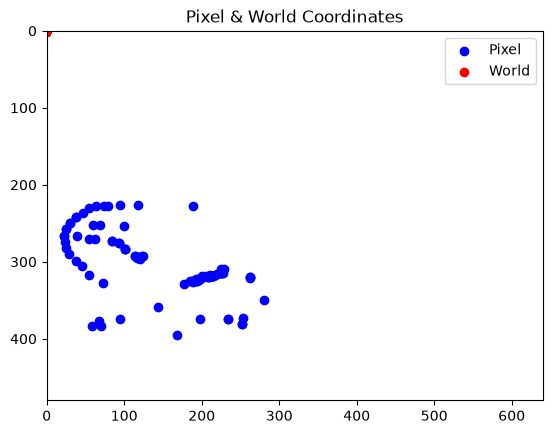

pixel: (223, 309) | world: (-0.92, 0.65)
pixel: (222, 307) | world: (-0.93, 0.63)
pixel: (225, 305) | world: (-0.90, 0.61)


<Figure size 640x480 with 0 Axes>

pixel: (225, 303) | world: (-0.90, 0.60)
pixel: (225, 301) | world: (-0.90, 0.58)
pixel: (225, 301) | world: (-0.90, 0.58)


<Figure size 640x480 with 0 Axes>

pixel: (225, 302) | world: (-0.90, 0.59)
pixel: (226, 302) | world: (-0.89, 0.59)
pixel: (223, 301) | world: (-0.92, 0.58)


...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [36]:
if __name__ == "__main__":
    main()